In [1]:
import pandas as pd

df_jugadores = pd.read_csv('../datos/jugadores_cebollitas.csv')
print(df_jugadores.columns)

Index(['jugador_id', 'nombre', 'posición', 'edad', 'partidos_jugados', 'goles',
       'asistencias', 'pases_completados (%)', 'tiros_al_arco',
       'precisión_tiros (%)', 'minutos_jugados'],
      dtype='object')


In [ ]:
# se pasan las variables completas, se usa kmeans
x = df_jugadores[['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']]
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df_jugadores['cluster'] = kmeans.fit_predict(x)

In [ ]:
# se analiza de forma avanzada, media de cada perfil
columnas_numericas = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
cluster_profile = df_jugadores.groupby('cluster')[columnas_numericas].mean()
print(cluster_profile)

         goles  asistencias  pases_completados (%)  tiros_al_arco
cluster                                                          
0          3.6          3.6                  80.04           44.8
1          2.6          4.9                  87.29            3.3
2          2.6          4.4                  78.34            9.0


/tmp/ipykernel_32414/3338237964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


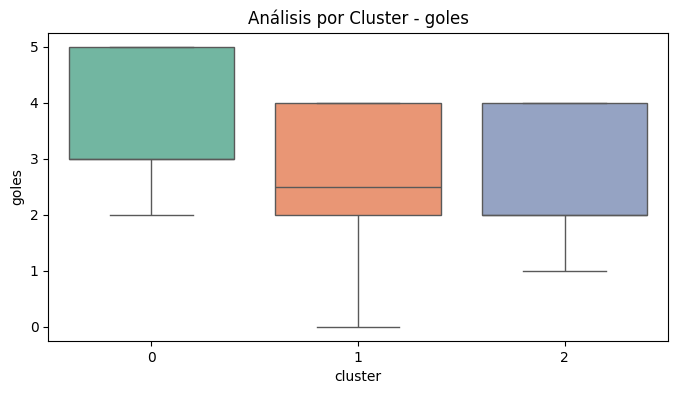

/tmp/ipykernel_32414/3338237964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


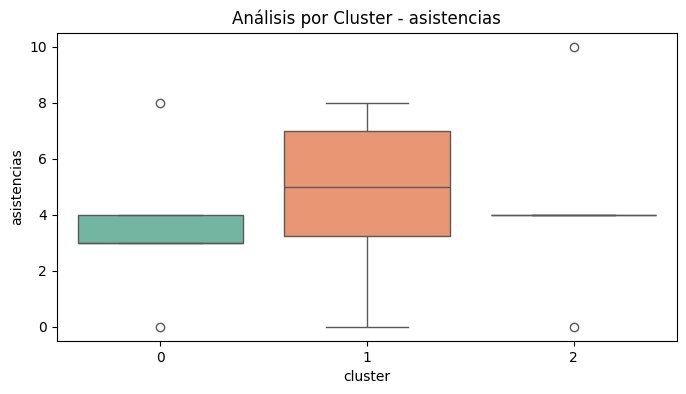

/tmp/ipykernel_32414/3338237964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


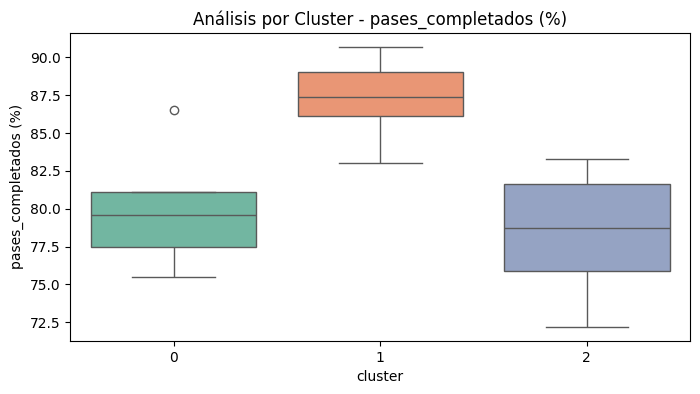

/tmp/ipykernel_32414/3338237964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')


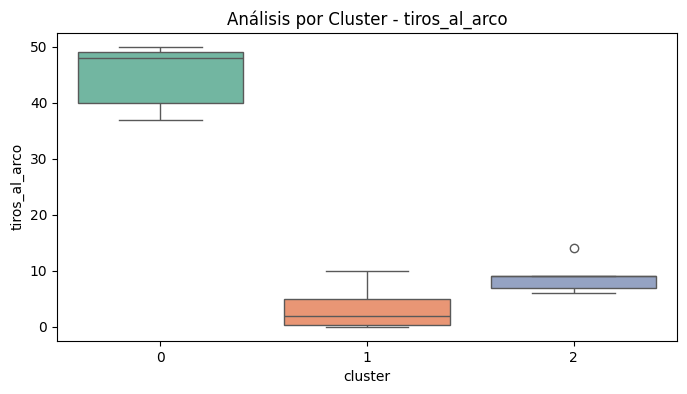

In [ ]:
# muestra  la media(goles, asistencia, pases_completado y tiros al arco) 
import matplotlib.pyplot as plt
import seaborn as sns

features = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']

for feature in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='cluster', y=feature, data=df_jugadores, palette='Set2')
    plt.title(f'Análisis por Cluster - {feature}')
    plt.show()

In [ ]:
# muestra los jugadores con sus caracteristicas claves
import ipywidgets as widgets
from IPython.display import display

# dropdown interativo
cluster_selector = widgets.Dropdown(
    options=sorted(df_jugadores['cluster'].unique()),
    description='cluster: '
)

# funcion de despliegue
def mostrar_jugadores(cluster):
    jugadores = [df_jugadores['cluster'] == cluster]
    display[jugadores[['nombre', 'goles', 'asistencias', 'pases_completados (%)', 'tiro_al_arco']]]

# activar el widget
widgets.interactive(mostrar_jugadores, cluster=cluster_selector)